In [72]:
import re
from collections import Counter

import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd
import seaborn as sns
from nltk import sent_tokenize, word_tokenize
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import SVC
from tensorflow.keras.layers import Embedding, TextVectorization



In [73]:
path = r"/home/lenovo/Projects/Deep-Learning-Lab/data/SMS dataset/SMSSpamCollection"

df = pd.read_csv(
    path,
    sep="\t",
    header=None,
    names=["label", "message"])

In [74]:
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [75]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   label    5572 non-null   str  
 1   message  5572 non-null   str  
dtypes: str(2)
memory usage: 542.9 KB


In [76]:
df["label"] = df["label"].replace("ham", "not_spam")

In [77]:
df.shape # (5572, 2)

(5572, 2)

In [78]:
df["label"].value_counts()

label
not_spam    4825
spam         747
Name: count, dtype: int64

In [79]:
df["label"].value_counts(normalize= True).round(2)

label
not_spam    0.87
spam        0.13
Name: proportion, dtype: float64

In [80]:
df.loc[df["label"] == "not_spam", "message"].iloc[0]

'Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...'

In [81]:
df.loc[df["label"] == "spam", "message"].iloc[0]

"Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's"

In [82]:
print(len(df.loc[df["label"] == "spam", "message"].iloc[0])) # 155
print(len(df.loc[df["label"] == "not_spam", "message"])) # 4825
print(len(df["message"].iloc[0])) # 111

155
4825
111


In [83]:
not_spam_max_length = df.loc[df["label"] == "not_spam", "message"].str.len().max()
print(not_spam_max_length)

910


In [84]:
spam_max_length = df.loc[df["label"] == "spam", "message"].str.len().max()
print(spam_max_length)

223


In [85]:
df.groupby("label")["message"].apply(lambda x: x.str.len().agg([min, max]))

label        
not_spam  min      2
          max    910
spam      min     13
          max    223
Name: message, dtype: int64

In [86]:
print(type(df["message"].iloc[0]))
print(len(df["message"].iloc[0]))
print(df["message"].iloc[0])

<class 'str'>
111
Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...


In [87]:
df.loc[df["message"].str.len() == 2, ["label", "message"]]

,label,message
1925,not_spam,Ok
3051,not_spam,Ok
4498,not_spam,Ok
5357,not_spam,Ok


In [88]:
(df.groupby("label")["message"].apply(lambda x: x.str.len().agg([np.mean, min, max]))).round(2)

label         
not_spam  mean     71.48
          min       2.00
          max     910.00
spam      mean    138.67
          min      13.00
          max     223.00
Name: message, dtype: float64

In [89]:
df.groupby("label")["message"].apply(lambda x: x.str.len().median())

label
not_spam     52.0
spam        149.0
Name: message, dtype: float64

| Label      | Mean   | Median | Min | Max |
|------------|--------|--------|-----|-----|
| `not_spam` | 71.48  | 52     | 2   | 910 |
| `spam`     | 138.67 | 149    | 13  | 223 |

In [90]:
df.loc[df["message"].str.len() == df["message"].str.len().max(), ["label", "message"]]

,label,message
1085,not_spam,For me the love should start with attraction.i...


In [91]:
df.loc[df["message"].str.len() == df["message"].str.len().min(), ["label", "message"]]

,label,message
1925,not_spam,Ok
3051,not_spam,Ok
4498,not_spam,Ok
5357,not_spam,Ok


In [92]:
df.loc[
    
    (df["label"] == "spam")
    &
    (df["message"].str.len() == df.loc[df["label"] == "spam", "message"].str.len().max())
]

,label,message
1734,spam,"Hi, this is Mandy Sullivan calling from HOTMIX..."


In [93]:
print((df["message"].str.strip() == "").sum())

0


In [94]:
print((df["message"].duplicated()).sum())

403


In [95]:
df.loc[df["message"].duplicated(), ["label", "message"]]

,label,message
103,not_spam,As per your request 'Melle Melle (Oru Minnamin...
154,not_spam,As per your request 'Melle Melle (Oru Minnamin...
207,not_spam,"As I entered my cabin my PA said, '' Happy B'd..."
223,not_spam,"Sorry, I'll call later"
326,not_spam,No calls..messages..missed calls
...,...,...
5524,spam,You are awarded a SiPix Digital Camera! call 0...
5535,not_spam,"I know you are thinkin malaria. But relax, chi..."
5539,not_spam,Just sleeping..and surfing
5553,not_spam,Hahaha..use your brain dear


In [96]:
df.groupby("label")["message"].nunique().value_counts()

message
4516    1
653     1
Name: count, dtype: int64

In [97]:
df.groupby("message")["label"].nunique().value_counts()

label
1    5169
Name: count, dtype: int64

In [98]:
def clean_text(text):

    # Convert uppercase English letters to lowercase
    text = re.sub(
        r"[A-Z]",
        lambda match: match.group().lower(),
        text
    )

    # Remove HTTP, HTTPS, and WWW URLs
    url_pattern = r"\b(?:https?://|www\.)\w+\.\w+\b"

    text = re.sub(
        url_pattern,
        "",
        text
    )

    # Remove special characters while keeping letters, numbers, and whitespace
    text = re.sub(
        r"[^a-zA-Z0-9\s+]",
        "",
        text
    )

    # Remove leading and trailing whitespace
    text = re.sub(
        r"^\s+|\s+$",
        "",
        text
    )

    # Replace consecutive whitespace characters with a single space
    text = re.sub(
        r"\s+",
        " ",
        text
    )

    return text.strip()

In [99]:
df["cleaned_message"] = df["message"].apply(clean_text)

In [100]:
sample = df.loc[df["cleaned_message"].str.len() == df["cleaned_message"].str.len().max(), "cleaned_message"].iloc[0]

In [101]:
word_token = word_tokenize(sample)
len(word_token)

171

In [102]:
sentence_token = sent_tokenize(sample)
len(sentence_token)

1

In [103]:
char_token = list(sample)
print(char_token)

['f', 'o', 'r', ' ', 'm', 'e', ' ', 't', 'h', 'e', ' ', 'l', 'o', 'v', 'e', ' ', 's', 'h', 'o', 'u', 'l', 'd', ' ', 's', 't', 'a', 'r', 't', ' ', 'w', 'i', 't', 'h', ' ', 'a', 't', 't', 'r', 'a', 'c', 't', 'i', 'o', 'n', 'i', ' ', 's', 'h', 'o', 'u', 'l', 'd', ' ', 'f', 'e', 'e', 'l', ' ', 't', 'h', 'a', 't', ' ', 'i', ' ', 'n', 'e', 'e', 'd', ' ', 'h', 'e', 'r', ' ', 'e', 'v', 'e', 'r', 'y', ' ', 't', 'i', 'm', 'e', ' ', 'a', 'r', 'o', 'u', 'n', 'd', ' ', 'm', 'e', 's', 'h', 'e', ' ', 's', 'h', 'o', 'u', 'l', 'd', ' ', 'b', 'e', ' ', 't', 'h', 'e', ' ', 'f', 'i', 'r', 's', 't', ' ', 't', 'h', 'i', 'n', 'g', ' ', 'w', 'h', 'i', 'c', 'h', ' ', 'c', 'o', 'm', 'e', 's', ' ', 'i', 'n', ' ', 'm', 'y', ' ', 't', 'h', 'o', 'u', 'g', 'h', 't', 's', 'i', ' ', 'w', 'o', 'u', 'l', 'd', ' ', 's', 't', 'a', 'r', 't', ' ', 't', 'h', 'e', ' ', 'd', 'a', 'y', ' ', 'a', 'n', 'd', ' ', 'e', 'n', 'd', ' ', 'i', 't', ' ', 'w', 'i', 't', 'h', ' ', 'h', 'e', 'r', 's', 'h', 'e', ' ', 's', 'h', 'o', 'u', 'l',

In [104]:
df["tokens"] = df["cleaned_message"].apply(nltk.word_tokenize) 

In [105]:
type(df["tokens"][0][0])

str

In [106]:
all_tokens = []

for token in df["tokens"]:
    all_tokens.extend(token)
    
    
vocabulary = set(all_tokens)


print("Total tokens:", len(all_tokens))
print("Vocabulary size:", len(vocabulary))

Total tokens: 85580
Vocabulary size: 9547


In [107]:
vectorizer = CountVectorizer()

X_bow = vectorizer.fit_transform(df["cleaned_message"])

vocabulary = vectorizer.vocabulary_
feature = vectorizer.get_feature_names_out()
print(X_bow.shape)
print(len(vocabulary))

(5572, 9495)
9495


In [108]:
df_matrix  = pd.DataFrame(X_bow[:10].toarray(), columns =feature )

In [109]:
vectorizer = TfidfVectorizer()
X_tfidf = vectorizer.fit_transform(df["cleaned_message"])
features = vectorizer.get_feature_names_out()
print(X_tfidf.shape)
print(features)

(5572, 9495)
['008704050406' '0089my' '0121' ... 'zoom' 'zouk' 'zyada']


In [110]:
pd.DataFrame(
    X_tfidf.toarray(),
    columns=features
)

,008704050406,0089my,0121,01223585236,01223585334,0125698789,02,020603,0207,02070836089,...,zebra,zed,zeros,zhong,zindgi,zoe,zogtorius,zoom,zouk,zyada
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5567,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5568,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5569,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5570,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [111]:
first_vector = X_tfidf[0]

print(round(first_vector, 2))

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 18 stored elements and shape (1, 9495)>
  Coords	Values
  (0, 1177)	0.33
  (0, 1415)	0.25
  (0, 1888)	0.31
  (0, 1890)	0.27
  (0, 2228)	0.27
  (0, 2514)	0.25
  (0, 3817)	0.15
  (0, 3874)	0.15
  (0, 3914)	0.18
  (0, 4432)	0.11
  (0, 4721)	0.33
  (0, 4882)	0.27
  (0, 6081)	0.16
  (0, 6489)	0.25
  (0, 8341)	0.16
  (0, 8778)	0.23
  (0, 9037)	0.19
  (0, 9285)	0.22


In [112]:
encoder = LabelEncoder()
X = X_tfidf
y = encoder.fit_transform(df["label"])

In [113]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42, stratify=y)

In [114]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (4457, 9495)
X_test: (1115, 9495)
y_train: (4457,)
y_test: (1115,)


In [115]:
lr = LogisticRegression()
basic_model = lr.fit(X_train, y_train)

y_pred = basic_model.predict(X_test)

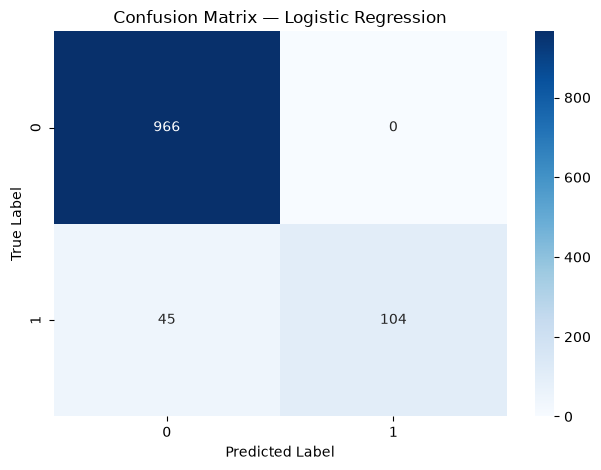

In [116]:
plt.figure()
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm,
    cmap="Blues",
    annot=True,
    fmt = "d",
    cbar = True)

plt.title("Confusion Matrix — Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()

plt.show()

In [117]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98       966
           1       1.00      0.70      0.82       149

    accuracy                           0.96      1115
   macro avg       0.98      0.85      0.90      1115
weighted avg       0.96      0.96      0.96      1115



In [118]:
print(f"accuracy score : {accuracy_score(y_test, y_pred):2f}")
print(f"precision score : {precision_score(y_test, y_pred):2f}")
print(f"recall score : {recall_score(y_test, y_pred):2f}")
print(f"F1 score : {f1_score(y_test, y_pred):2f}")

accuracy score : 0.959641
precision score : 1.000000
recall score : 0.697987
F1 score : 0.822134


Model: Logistic Regression
Features: TF-IDF
Accuracy: 95.96%
Precision: 100.00%
Recall: 69.80%
F1: 82.21%

In [119]:
y_prob = basic_model.predict_proba(X_test)[: , 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)
print(f"ROC-AUC: {auc:.4f}")

ROC-AUC: 0.9867


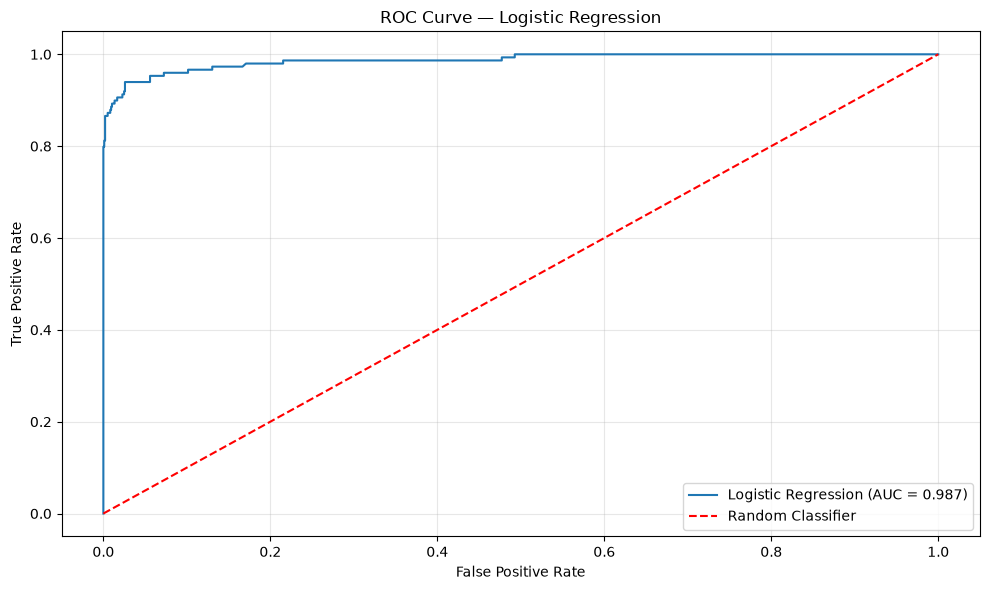

In [120]:
plt.figure(figsize=(10, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {auc:.3f})")

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="red",
    label="Random Classifier"
)




plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Logistic Regression")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [121]:
nb = MultinomialNB()
nb_model = nb.fit(X_train ,y_train)
y_pred = nb_model.predict(X_test)

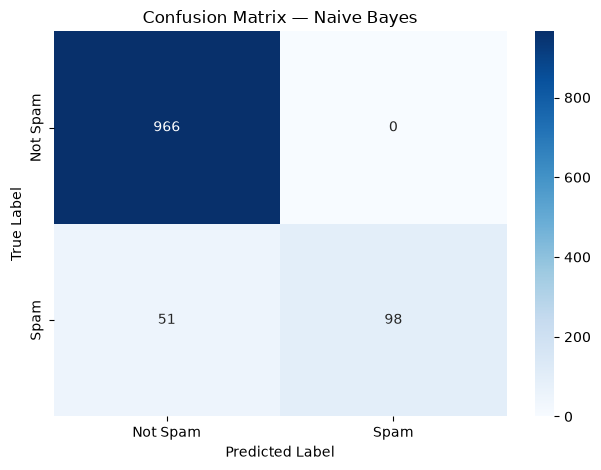

In [122]:
plt.figure()
cm_nb = confusion_matrix(y_test, y_pred)
sns.heatmap(cm_nb,
            cmap="Blues",
            annot=True,
            fmt="d",
            cbar=True,
            xticklabels=["Not Spam", "Spam"],
            yticklabels=["Not Spam", "Spam"])


plt.title("Confusion Matrix — Naive Bayes")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()
plt.show()

In [123]:
print(f"accuracy score : {accuracy_score(y_test, y_pred):2f}")
print(f"precision score : {precision_score(y_test, y_pred):2f}")
print(f"recall score : {recall_score(y_test, y_pred):2f}")
print(f"F1 score : {f1_score(y_test, y_pred):2f}")

accuracy score : 0.954260
precision score : 1.000000
recall score : 0.657718
F1 score : 0.793522


In [124]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      1.00      0.97       966
           1       1.00      0.66      0.79       149

    accuracy                           0.95      1115
   macro avg       0.97      0.83      0.88      1115
weighted avg       0.96      0.95      0.95      1115



| Model               | Accuracy | Precision | Recall | F1 Score |
|---------------------|----------|-----------|--------|----------|
| Logistic Regression | 0.9596   | 1.0000    | 0.6980 | 0.8221   |
| Naive Bayes         | 0.9543   | 1.0000    | 0.6577 | 0.7935   |

In [125]:
pipeline = Pipeline([
    ("svc", SVC())
])

svc_param = {
    "svc__C": [0.1, 1, 10],
    "svc__kernel": ["linear", "rbf"],
    "svc__gamma": ["scale", "auto"]
}

svc_grid = GridSearchCV(
    pipeline,
    param_grid=svc_param,
    n_jobs = -1,
    verbose=1,
    scoring= "f1",
    cv= 5
    )

model_svc = svc_grid.fit(
    X_train,
    y_train)

y_pred = model_svc.predict(X_test)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


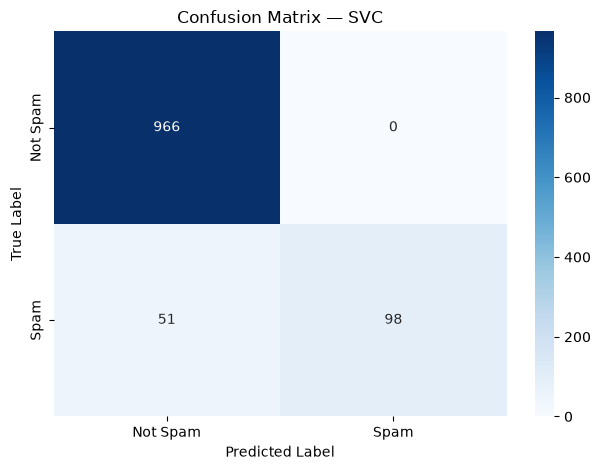

In [126]:
plt.figure()
cm_svc = confusion_matrix(y_test, y_pred)
sns.heatmap(cm_nb,
            cmap="Blues",
            annot=True,
            fmt="d",
            cbar=True,
            xticklabels=["Not Spam", "Spam"],
            yticklabels=["Not Spam", "Spam"])


plt.title("Confusion Matrix — SVC")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()
plt.show()

In [127]:
print(f"accuracy score : {accuracy_score(y_test, y_pred):2f}")
print(f"precision score : {precision_score(y_test, y_pred):2f}")
print(f"recall score : {recall_score(y_test, y_pred):2f}")
print(f"F1 score : {f1_score(y_test, y_pred):2f}")

accuracy score : 0.983857
precision score : 1.000000
recall score : 0.879195
F1 score : 0.935714


In [128]:
print(model_svc.best_params_)
print(model_svc.best_score_)

{'svc__C': 10, 'svc__gamma': 'scale', 'svc__kernel': 'linear'}
0.9211512840071192


In [129]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       966
           1       1.00      0.88      0.94       149

    accuracy                           0.98      1115
   macro avg       0.99      0.94      0.96      1115
weighted avg       0.98      0.98      0.98      1115



In [130]:
df.columns # Index(['label', 'message', 'cleaned_message', 'tokens'], dtype='str')

Index(['label', 'message', 'cleaned_message', 'tokens'], dtype='str')

In [131]:
texts = df["cleaned_message"]
labels = df["label"]

In [132]:
X_train, X_test, y_train, y_test = train_test_split(
    texts,
    labels,
    test_size=0.2,
    random_state=42,
    stratify = labels
)

In [133]:
vectorizer = TextVectorization(
    max_tokens= 10000,
    output_mode="int",
    output_sequence_length=50)

In [134]:
vectorizer.adapt(X_train)

In [135]:
vocabulary = vectorizer.get_vocabulary()
print(vocabulary[:20])

['', '[UNK]', np.str_('to'), np.str_('i'), np.str_('you'), np.str_('a'), np.str_('the'), np.str_('u'), np.str_('and'), np.str_('in'), np.str_('is'), np.str_('my'), np.str_('me'), np.str_('for'), np.str_('your'), np.str_('it'), np.str_('of'), np.str_('call'), np.str_('have'), np.str_('on')]


In [136]:
sample = X_train.iloc[0]
print(sample)

he will you guys close


In [137]:
sequnce = vectorizer(sample)
print(sequnce)

tf.Tensor(
[ 75  33   4 314 666   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0], shape=(50,), dtype=int64)


In [138]:
train_sequence = vectorizer(X_train)
test_sequence = vectorizer(X_test)

In [139]:
sequence_lengths = X_train.apply(
    lambda x: len(x.split())
)
print(sequence_lengths.describe())

count    4457.000000
mean       15.196993
std        10.719190
min         0.000000
25%         7.000000
50%        12.000000
75%        22.000000
max       171.000000
Name: cleaned_message, dtype: float64


In [140]:
print(
    sequence_lengths.quantile(
        [0.90, 0.95, 0.97, 0.98, 0.99, 1.00]
    )
)

0.90     28.0
0.95     32.0
0.97     34.0
0.98     38.0
0.99     51.0
1.00    171.0
Name: cleaned_message, dtype: float64


In [141]:
sequence = vectorizer(X_train.iloc[0])

print(sequence)
print(sequence.shape)

tf.Tensor(
[ 75  33   4 314 666   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0], shape=(50,), dtype=int64)
(50,)


In [ ]:
embedding = Embedding(
    input_dim=10000,
    output_dim=64,
    mask_zero=True
)